In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

warnings.filterwarnings('ignore')
%matplotlib inline

pd.options.display.float_format = '{:.0f}'.format
sns.set_theme(style='whitegrid')

## Business Probelm Understanding
The Business behind this Dataset is Divar, the biggest online classified ads and e-commerce platform in Iran.
Divar's largest listing category is real-estate ads.
In this notebook, we use the  dataset which divar published in 2024, inviting Data Analysts and other professionals to join them in finding possible doors to new useful features for divars users, and solving problems related to the business.
The main idea here is to predict house prices given the listings data, so it can be used in many features, for example:
1. a standalone prodoct that helps advertisers estimate the price of their properties
2. a measure for evaluating posted advertisments prices, to give insight to the end user which is searching for properties
3. a measure for finding possible pricing/ listing availability frauds and data anomolies within the listings
and possibly many other use cases!

## 1. Data Collection

In [ ]:
# Here you can find the dataset online: https://huggingface.co/datasets/divarofficial/real_estate_ads#
file_path = 'real_estate_ads.csv'
df = pd.read_csv(file_path, low_memory=False)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (1000000, 60)


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,...,NaN,4,6,350000,1500000,3500000000,3500000,36,51,500
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,51,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Real Estate Ads - Comprehensive Exploratory Data Analysis (EDA)
The dataset is quite large, containing 1,000,000 entries and 60 columns.

In [ ]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   cat2_slug                   1000000 non-null  object 
 1   cat3_slug                   999999 non-null   object 
 2   city_slug                   999998 non-null   object 
 3   neighborhood_slug           437139 non-null   object 
 4   created_at_month            1000000 non-null  object 
 5   user_type                   288882 non-null   object 
 6   description                 1000000 non-null  object 
 7   title                       999946 non-null   object 
 8   rent_mode                   352994 non-null   object 
 9   rent_value                  351322 non-null   float64
 10  rent_to_single              19 non-null       object 
 11  rent_type                   103961 non-null   object 
 12  price_mode                  573606 non-null   object 
 13

In [ ]:
# this table shows how much null values we have per column
null_percentages = round((df.isnull().sum() / len(df) * 100))
column_has_null = null_percentages[null_percentages > 0]
df_null= pd.DataFrame(column_has_null.values, column_has_null.index)
print("number of columns with null values: ", len(df_null))
display(df_null.head(15))

number of columns with null values:  54


,0
neighborhood_slug,56
user_type,71
rent_mode,65
rent_value,65
rent_to_single,100
rent_type,90
price_mode,43
price_value,43
credit_mode,65
credit_value,65


In [ ]:
display(df.describe())

,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,351322,568346,352095,352085,72409,351248,72409,186396,980394,29870,10241,18068,10463,13551,655608,655608,339699
mean,41022993842,17365370640,48720843307,48722218216,8557025436,41031635748,16199337,4165,4441,7,12097853225,138901595343,23555479873,31565505114,35,52,465
std,3807534359773,587873885224,4341345683533,4341407327546,2064576077065,3807935373875,52178904,121893,136712,8,1103481904299,7042334684882,1542048595012,2434942028116,2,3,126
min,0,0,0,0,0,0,0,1,1,1,0,0,0,0,24,40,0
25%,111111,1400000000,100000000,100000000,200000000,111111,1000000,110,75,3,50000,400000,600000,550000,35,51,500
50%,5000000,2840000000,250000000,250000000,400000000,5000000,6000000,195,103,4,100000,800000,1200000,1100000,36,51,500
75%,12000000,5900000000,500000000,500000000,850000000,12000000,15000000,280,165,7,200000,1600000,2500000,2500000,36,52,500
max,999999999999999,99999999999999,999999999999999,999999999999999,555555555555555,999999999999999,3000000000,10000000,10000000,50,111111111111111,500600700800900,111111111111111,200250300400450,40,75,500


In [ ]:
# Finding possible outliers
# Initialize df_ml by filtering the main dataframe for 'sell' properties
df_sell = df[df['cat2_slug'].str.contains('sell', na=False)].copy()

def outliers(group):
  # we use IQR method, which is used to measure dispersion of a dataset. the goal is to find the outliers by dividing dataset into quartiles.
  Q1 = group['price_value'].quantile(0.25) #quantile is from pandas library
  Q3 = group['price_value'].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  # The multiplier 1.5 is a convention established by statistician John Tukey. It's an empirically derived value that typically works well across many datasets to identify observations that are unusually far from the bulk of the data without being overly sensitive to minor fluctuations. Values outside this 1.5 * IQR range are often considered 'mild outliers,' while 3 * IQR is sometimes used for 'extreme outliers.'
  # now we Identify outliers:
  group['outlier_price'] = (group['price_value'] < lower_bound) | (group['price_value'] > upper_bound)
  group['outlier_type'] = ''
  group.loc[group['price_value'] < lower_bound, 'outlier_type'] = 'too cheap'
  group.loc[group[group['price_value'] > upper_bound].index, 'outlier_type'] = 'too expensive'
  return group

# price of houses mostly depend on city and property type so we group the prices by these parameters and then find outliers of these groups using the before function of outliers
df_outliers = df_sell.groupby(['city_slug', 'cat3_slug']).apply(outliers)
outlier_listings = df_outliers[df_outliers['outlier_price'] == True]

print(f"percentage of price outliers found is {round(len(outlier_listings) / len(df_sell) * 100, 2)}%")
print("\nexample of outliers:")
display(outlier_listings[['cat2_slug', 'cat3_slug', 'city_slug', 'created_at_month', 'title', 'outlier_type', 'price_value']].head())

percentage of price outliers found is 7.88%

example of outliers:


cat2_slug         cat3_slug  \
city_slug cat3_slug                                                     
Iranshahr apartment-sell   458610  residential-sell    apartment-sell   
                           937233  residential-sell    apartment-sell   
          house-villa-sell 95840   residential-sell  house-villa-sell   
                           230260  residential-sell  house-villa-sell   
                           299182  residential-sell  house-villa-sell   

                                   city_slug     created_at_month  \
city_slug cat3_slug                                                 
Iranshahr apartment-sell   458610  Iranshahr  2024-10-01 00:00:00   
                           937233  Iranshahr  2024-10-01 00:00:00   
          house-villa-sell 95840   Iranshahr  2024-11-01 00:00:00   
                           230260  Iranshahr  2024-07-01 00:00:00   
                           299182  Iranshahr  2024-08-01 00:00:00   

                                                                        title  \
city_slug cat3_slug                                                             
Iranshahr apartment-sell   458610  2واحد آپارتمان مسکن مهرباهم به فروش می رسد   
                           937233                                   منزل۳طبقه   
          house-villa-sell 95840        منزل فروشی سه طبقه سجادشهر بلوچستان ۹   
                           230260                    منزل ویلایی کشاورز جنوبی   
                           299182             ملک  تجاری ومسکونی بربلوار اصلی   

                                    outlier_type  price_value  
city_slug cat3_slug                                            
Iranshahr apartment-sell   458610  too expensive  11111111111  
                           937233  too expensive   6000000000  
          house-villa-sell 95840   too expensive   7500000000  
                           230260  too expensive   6500000000  
                           299182  too expensive   9000000000

## Data exploration discussion
The dataset features a mix of categorical, boolean flags and numerical attributes.
####Data Quality Issues:</br>
**Missing Values**: 54 out of 60 columns were null, we can assume that besides the 'created_at_month' field, the 5 columns left are the mandatory fields for every listings.
It's important to consider that although the missing values shouldn't all be accounted as poor quality data (because the mandatory fields per listin category (cat2_slug and cat3_slug) could possibly be different), we still need to do pre-processing and feature engineering for these values.<br>
**Multilingual Data**: The presence of Persian text (city_slug, title, description, construction_year) requires specific handling for parsing and processing.

**Outliers**: 7.53% of listing prices were outliers according to our definition of outliers. (we used IQR method, trying to keep the pipline not too complicated)

###Evaluation Metrics:
Given the main objective is to predict house prices, that is a regression task, the chosen evaluation metrics are:
1. R-squared
2. Root Mean Squared Error (RMSE)

## 3. Data Cleaning and Preprocessing
Removing Columns with too many missing values, outliers, Converting datatypes and handling specific textual format details.

In [ ]:
# Identify columns with more than 70% null values
columns_to_drop = null_percentages[null_percentages > 70].index.tolist()

# Drop these columns from the DataFrame
df.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped {len(columns_to_drop)} columns with more than 70% null values.")
print("Remaining columns:", df.shape[1])

display(df.head())

Dropped 23 columns with more than 70% null values.
Remaining columns: 37


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,description,title,rent_mode,rent_value,price_mode,...,is_rebuilt,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,building_direction,floor_material,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,51,500
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000,NaN,...,False,NaN,NaN,NaN,NaN,NaN,NaN,36,51,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,مقطوع,...,NaN,package,shoofaj,air_conditioner,squat_seat,north,ceramic,NaN,NaN,NaN


In [ ]:
# Remove outliers to create a cleaned dataset
df_cleaned = df_outliers[df_outliers['outlier_price'] == False].copy()

print(f"Original dataset size: {len(df_sell)}")
print(f"Dataset size after outlier removal: {len(df_cleaned)}")
print(f"Number of outliers removed: {len(df_sell) - len(df_cleaned)}")

Original dataset size: 597569
Dataset size after outlier removal: 550457
Number of outliers removed: 47112


In [ ]:
# Convert datetime format
df['created_at_month'] = pd.to_datetime(df['created_at_month'], errors='coerce')

# Normalize booleans that might be read as strings
bool_cols = [col for col in df.columns if col.startswith('has_') or col.startswith('is_')]
for col in bool_cols:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.lower() == 'true'

# Standardize room count mapping to integers to allow numeric analysis
room_map = {'یک': 1, 'دو': 2, 'سه': 3, 'چهار': 4, 'بدون اتاق': 0}
df['rooms_count_num'] = df['rooms_count'].map(room_map)

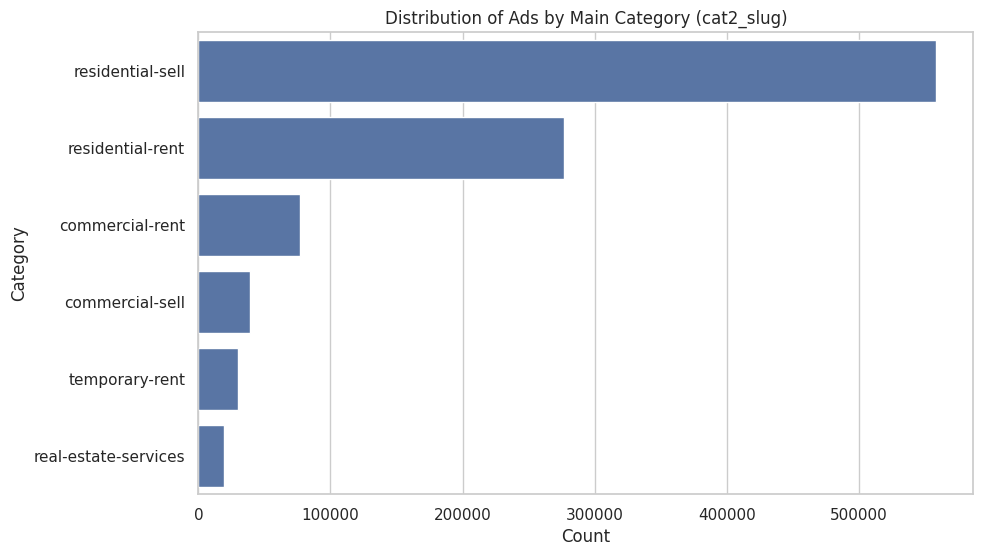

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='cat2_slug', order=df['cat2_slug'].value_counts().index)
plt.title('Distribution of Ads by Main Category (cat2_slug)')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

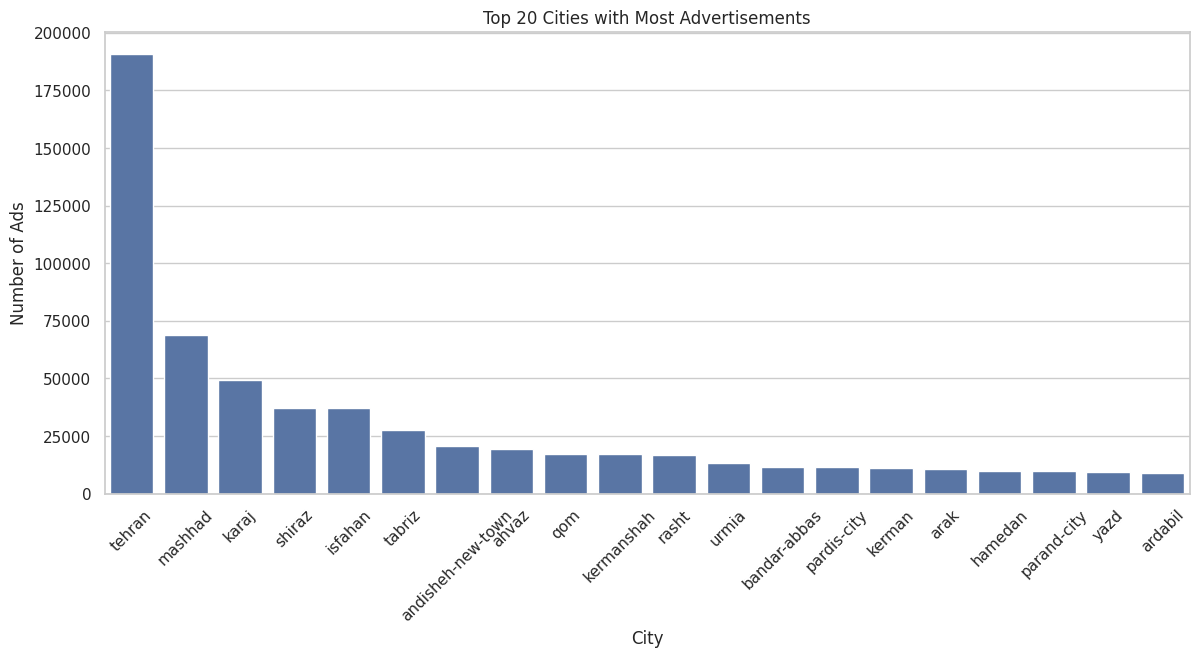

In [ ]:
top_cities = df['city_slug'].value_counts().head(20)
plt.figure(figsize=(14, 6))
sns.barplot(x=top_cities.index, y=top_cities.values)
plt.title('Top 20 Cities with Most Advertisements')
plt.xticks(rotation=45)
plt.ylabel('Number of Ads')
plt.xlabel('City')
plt.show()

### Distribution of Building Size
Filtering outliers visually to see the main distribution.

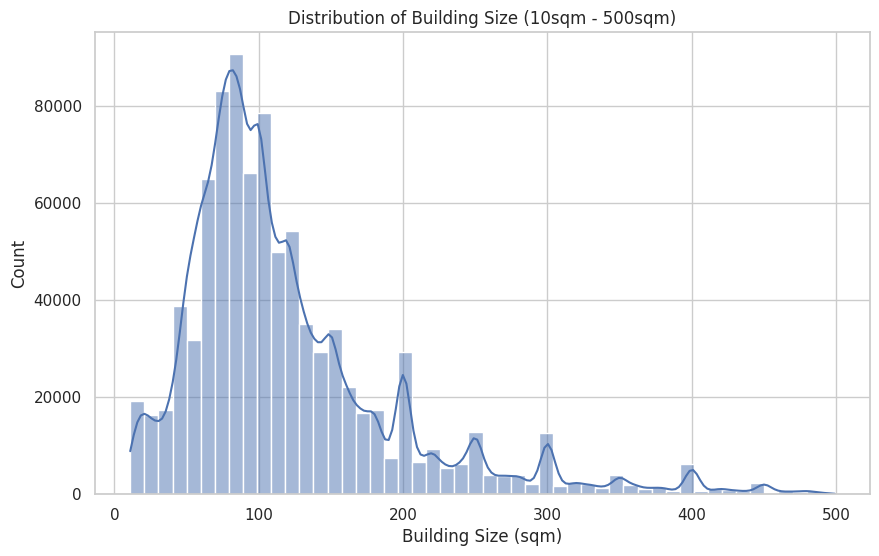

In [ ]:
size_filtered = df[(df['building_size'] > 10) & (df['building_size'] < 500)]
plt.figure(figsize=(10, 6))
sns.histplot(size_filtered['building_size'].dropna(), bins=50, kde=True)
plt.title('Distribution of Building Size (10sqm - 500sqm)')
plt.xlabel('Building Size (sqm)')
plt.ylabel('Count')
plt.show()

### Bivariate Analysis
Looking into properties vs cities, sizes, and specific features.

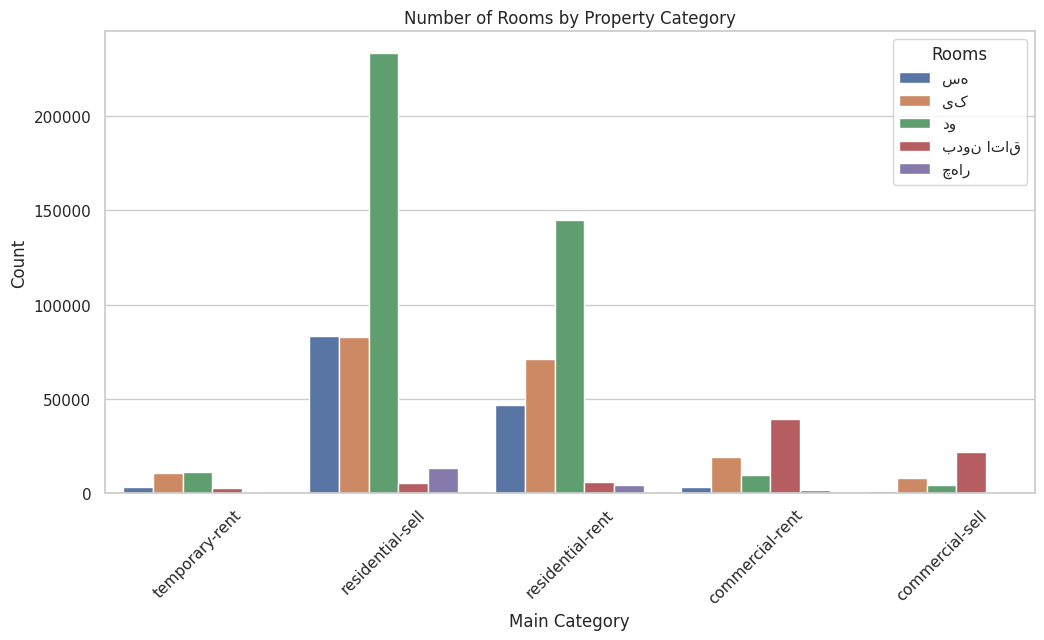

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['rooms_count'].isin(['یک', 'دو', 'سه', 'چهار', 'بدون اتاق'])],
             x='cat2_slug', hue='rooms_count')
plt.title('Number of Rooms by Property Category')
plt.xticks(rotation=45)
plt.xlabel('Main Category')
plt.ylabel('Count')
plt.legend(title='Rooms')
plt.show()

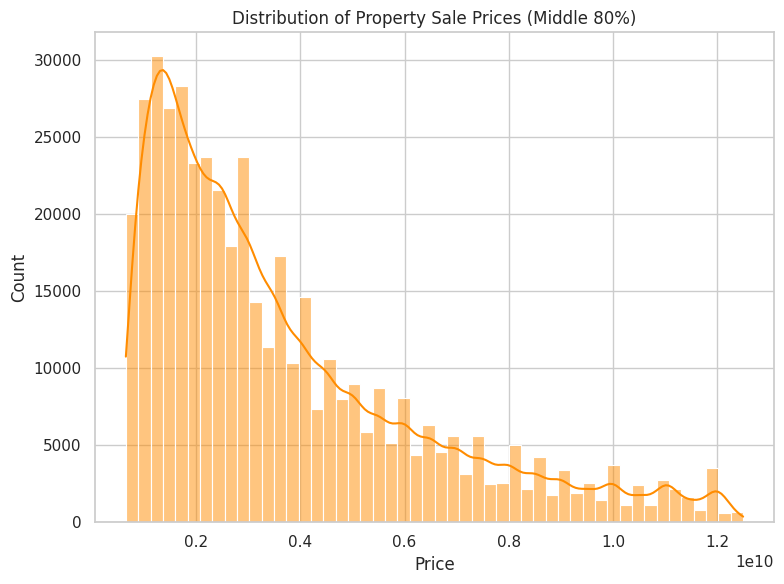

In [ ]:
# Grouping Sell Data and Filtering outliers
df_sell = df[df['cat2_slug'].str.contains('sell', na=False)]

def filter_price_outliers(data, col):
    if data[col].isnull().all(): return data
    return data[(data[col] > data[col].quantile(0.1)) & (data[col] < data[col].quantile(0.9))]

sell_filtered = filter_price_outliers(df_sell, 'price_value')

# Plot for sell prices
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(sell_filtered['price_value'], bins=50, kde=True, color='darkorange', ax=ax)
ax.set_title('Distribution of Property Sale Prices (Middle 80%)')
ax.set_xlabel('Price')
plt.tight_layout()
plt.show()

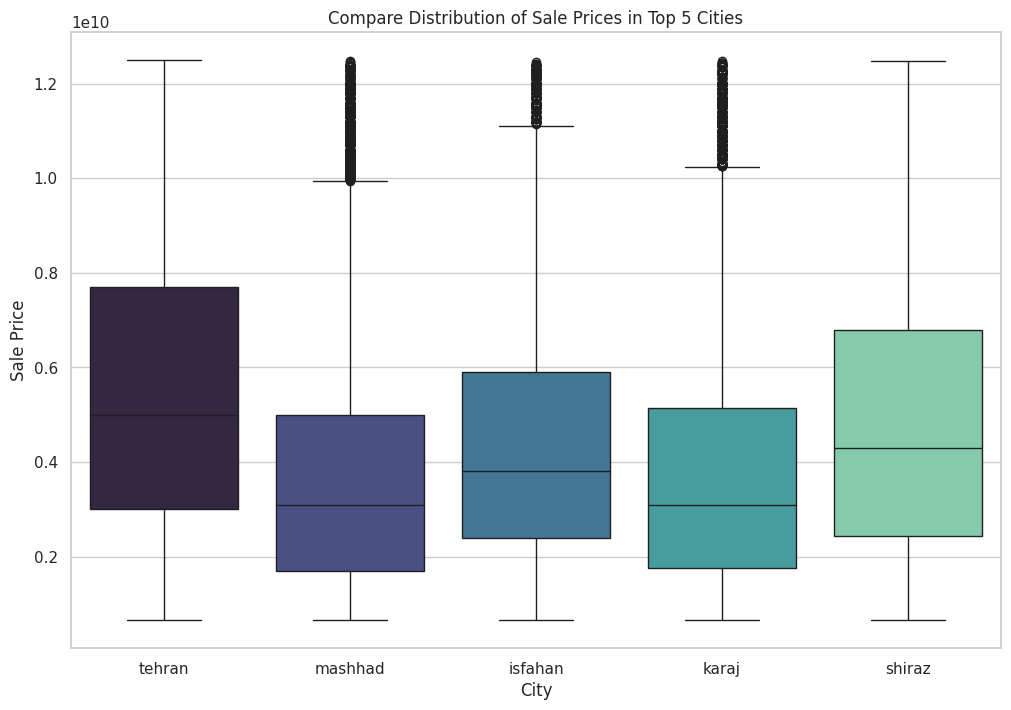

In [ ]:
top_5_cities = df_sell['city_slug'].value_counts().head(5).index
df_top5_sell = sell_filtered[sell_filtered['city_slug'].isin(top_5_cities)]

plt.figure(figsize=(12, 8))
sns.boxplot(x='city_slug', y='price_value', data=df_top5_sell, palette='mako')
plt.title('Compare Distribution of Sale Prices in Top 5 Cities')
plt.xlabel('City')
plt.ylabel('Sale Price')
plt.show()

### Correlation Analysis

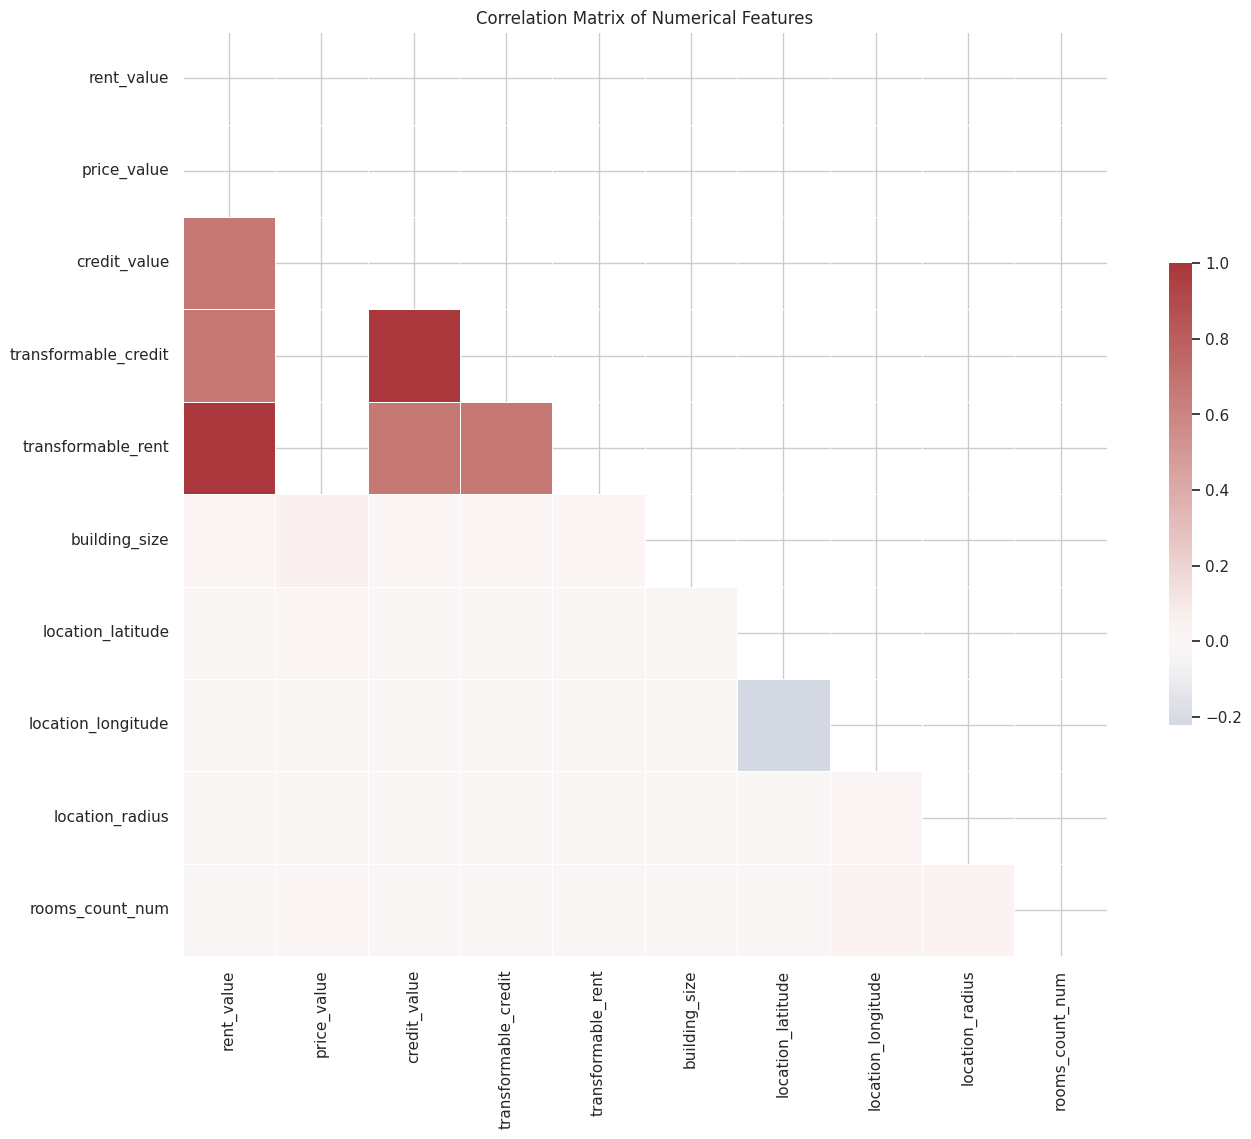

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='vlag', vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Geospatial Distribution (Sample)

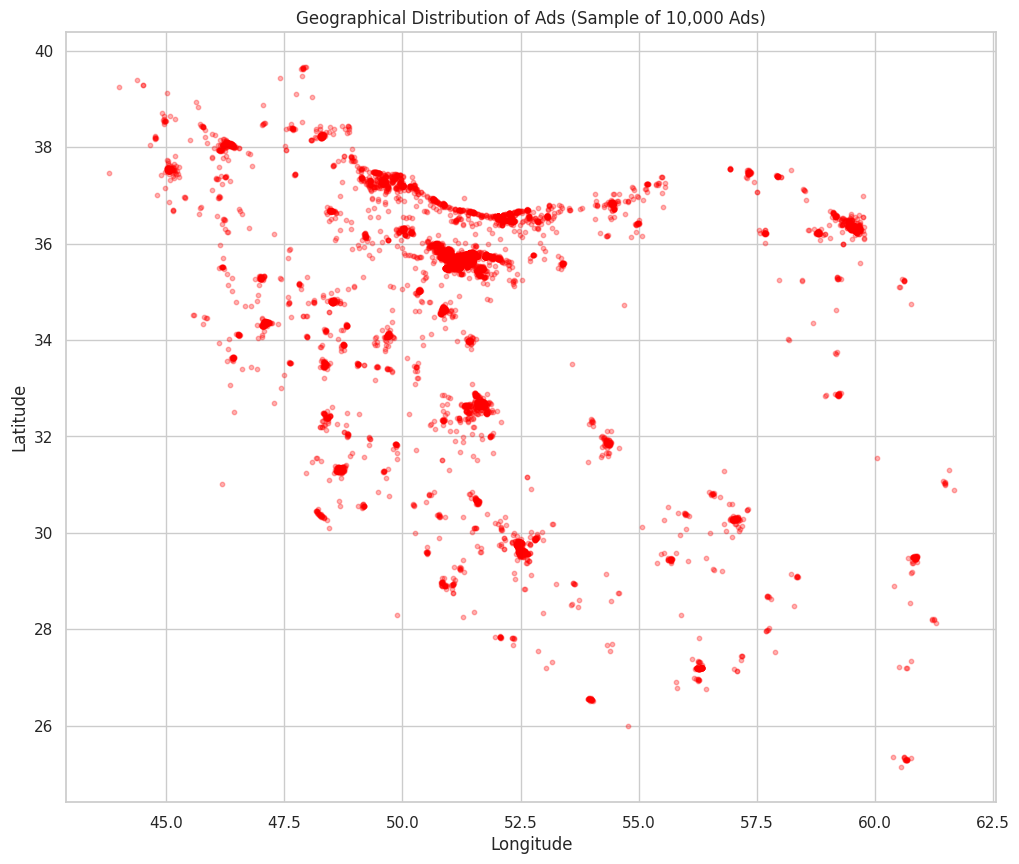

In [ ]:
sample_geo = df.dropna(subset=['location_latitude', 'location_longitude']).sample(min(10000, len(df)))
plt.figure(figsize=(12, 10))
plt.scatter(sample_geo['location_longitude'], sample_geo['location_latitude'], alpha=0.3, s=10, c='red')
plt.title('Geographical Distribution of Ads (Sample of 10,000 Ads)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

## 4. Feature Engineering

Since the goal is to predict property prices, we need to separate the dataset into **Sale Properties** and **Rent Properties**, because their pricing structures (Price vs. Rent + Deposit) are fundamentally different.

### Potential Features for Sale Price Prediction:
- **Target Variable**: `price_value`
- **Categorical Features**: `city_slug`, `neighborhood_slug`, `cat3_slug` (e.g., apartment vs. villa), `user_type`, `property_type`, `deed_type`.
- **Numerical Features**: `building_size`, `rooms_count_num`, `construction_year`, `total_floors_count`, `location_latitude`, `location_longitude`.
- **Boolean/Binary Features**: `has_elevator`, `has_parking`, `has_warehouse`, `has_pool`, etc.

### Feature Engineering For Sale Prices


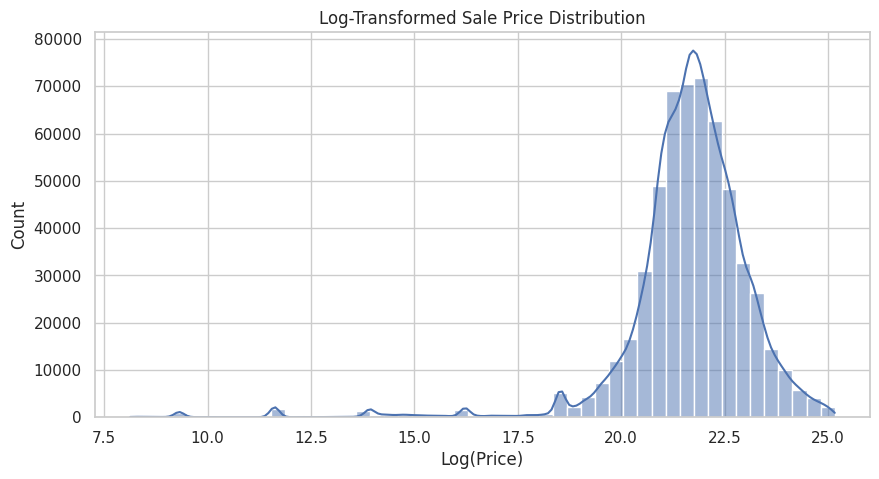

In [ ]:
# 1. Filter only "sell" properties
df_ml = df[df['cat2_slug'].str.contains('sell', na=False)].copy()

# 2. Handle Target Variable: Drop rows where price_value is missing, 0, or extremely low/high
df_ml = df_ml.dropna(subset=['price_value'])
df_ml = df_ml[(df_ml['price_value'] > df_ml['price_value'].quantile(0.01)) &
              (df_ml['price_value'] < df_ml['price_value'].quantile(0.99))]

# Apply Log Transformation to the target variable to reduce right-skewness
df_ml['log_price'] = np.log1p(df_ml['price_value'])

plt.figure(figsize=(10, 5))
sns.histplot(df_ml['log_price'], bins=50, kde=True)
plt.title('Log-Transformed Sale Price Distribution')
plt.xlabel('Log(Price)')
plt.show()

In [ ]:
# 3. Feature Engineering: Building Age
# Convert Persian year strings (e.g., "۱۳۹۵") to integers safely
def parse_persian_year(year_str):
    if pd.isna(year_str): return np.nan
    persian_to_eng = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')
    eng_num = str(year_str).translate(persian_to_eng)
    val = re.search(r'\d{4}', eng_num)
    if val: return int(val.group())
    if 'قبل از' in str(year_str): return 1369
    return np.nan

df_ml['construction_year_num'] = df_ml['construction_year'].apply(parse_persian_year)

# Assuming current Persian year is 1403
df_ml['building_age'] = 1403 - df_ml['construction_year_num']
df_ml['building_age'] = df_ml['building_age'].clip(lower=0) # ensure no negative age

# Clean main numerical feature: building_size
df_ml = df_ml.dropna(subset=['building_size'])
df_ml = df_ml[(df_ml['building_size'] > 10) & (df_ml['building_size'] < 1000)]

In [ ]:
# 4. Encoding Categorical Variables
# Group cities outside the top 20 into an "Other" bucket to avoid thousands of One-Hot dimensions
top_cities = df_ml['city_slug'].value_counts().nlargest(20).index
df_ml['city_grouped'] = df_ml['city_slug'].apply(lambda x: x if x in top_cities else 'Other')

# One-Hot Encode categorized columns using get_dummies
df_encoded = pd.get_dummies(df_ml, columns=['city_grouped', 'cat3_slug'], drop_first=True, dtype=int)

# Select final features
bool_cols_existing = [c for c in df_ml.columns if c.startswith('has_') and c in df_ml]
categorical_encoded_cols = [c for c in df_encoded.columns if c.startswith('city_grouped_') or c.startswith('cat3_slug_')]
selected_features = ['building_size', 'rooms_count_num', 'building_age'] + bool_cols_existing + categorical_encoded_cols

# Define X (features) and y (target)
X = df_encoded[selected_features].copy()
y = df_ml['log_price']

# Ensure numeric conversions and imputation for Missing Values
# We fill missing booleans with False (0).
# Safely convert boolean columns (handles standard bools, NaNs, and string 'true' / 'false')
for col in bool_cols_existing:
    X[col] = X[col].astype(str).str.lower() == 'true'
X[bool_cols_existing] = X[bool_cols_existing].astype(int)
X['building_age'] = X['building_age'].fillna(X['building_age'].median())
X['rooms_count_num'] = X['rooms_count_num'].fillna(X['rooms_count_num'].median())

print(f"Final feature matrix X shape: {X.shape}")
print(f"Final target vector y shape: {y.shape}")
display(X.head())

Final feature matrix X shape: (527735, 36)
Final target vector y shape: (527735,)


,building_size,rooms_count_num,building_age,has_balcony,has_elevator,has_warehouse,has_parking,has_warm_water_provider,has_heating_system,has_cooling_system,...,city_grouped_rasht,city_grouped_shiraz,city_grouped_tabriz,city_grouped_tehran,city_grouped_urmia,cat3_slug_house-villa-sell,cat3_slug_industry-agriculture-business-sell,cat3_slug_office-sell,cat3_slug_plot-old,cat3_slug_shop-sell
1,60,1,19,0,1,1,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,115,2,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,100,2,10,0,1,1,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
8,78,2,7,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,80,2,16,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5. Model Training

With the `X` (features) and `y` (target: log-transformed price) matrix prepared, we can proceed to model training:
1. **Train/Test Split**: Split data (80% training, 20% testing sets) using `train_test_split` from `sklearn`.
* Since the feature engineering involved only simple, row-wise transformations, and One-hot encoding for fixed, known categories (like city_slug or cat3_slug in our notebook) shouldn't lead to significant leakage, as the mapping itself is fixed. Yet we still set aside the Scaling as a step after the train/test split, because for techniques like `StandardScaler`, the scaler should only be fit on the training data and then used to transform both training and test data.
2. **Scaling**: Standardize continuous properties ('building_size', 'building_age') using `StandardScaler` to help regression models converge.
3. **Modeling Algorithm Options**:
    - **XGBoost / LightGBM Regression** (Highly recommended for this housing tabular data).
    - **Random Forest Regression**.
    - **Lasso/Ridge Regression** (For interpreting exact features parameter weighting).
4. **Evaluation**: Compare models mapping predicted `log_price` back into original range generating insights via **RMSE**, **MAE** & **$R^2$ Score**.

### How to use Location

The best practice in Data Science to find the "best" way to use location is to **let the data decide using Empirical Validation**. We can do this by training a quick baseline model on a subset of the data across three different strategies to see which yields the highest $R^2$ (accuracy) score.

### Strategies:
1. **Baseline**: Only using categorical `city_grouped` (What we did above).
2. **Raw Coordinates**: Adding `location_latitude` and `location_longitude` directly (Great for tree-based models).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans

# For speed in this experiment, let's use a 50,000 row random sample
df_exp = df_ml.dropna(subset=['location_latitude', 'location_longitude']).sample(min(50000, len(df_ml)), random_state=42)

# Get our base features for this sample
X_base = df_encoded.loc[df_exp.index, selected_features].copy()
# Clean boolean columns safely
for col in bool_cols_existing:
    X_base[col] = X_base[col].astype(str).str.lower() == 'true'
X_base[bool_cols_existing] = X_base[bool_cols_existing].astype(int)
X_base['building_age'] = X_base['building_age'].fillna(X_base['building_age'].median())
X_base['rooms_count_num'] = X_base['rooms_count_num'].fillna(X_base['rooms_count_num'].median())
y_exp = df_exp['log_price']

# Function to test and score strategies
def evaluate_strategy(X_data, y_data, strategy_name):
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
    # We use a DecisionTree for rapid prototyping
    model = DecisionTreeRegressor(max_depth=15, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = r2_score(y_test, preds)
    print(f"{strategy_name} R² Score: {score:.4f}")

# --- Strategy 1: Baseline ---
evaluate_strategy(X_base, y_exp, 'Strategy 1 (City Categories Only)')

# --- Strategy 2: Raw Coordinates ---
X_coords = X_base.copy()
X_coords['lat'] = df_exp['location_latitude']
X_coords['lon'] = df_exp['location_longitude']
evaluate_strategy(X_coords, y_exp, 'Strategy 2 (Raw Latitude/Longitude)')


Strategy 1 (City Categories Only) R² Score: -0.0544
Strategy 2 (Raw Latitude/Longitude) R² Score: -0.0716


### Strategy Evaluation - Finding the Best Algorithm

Based on previous discussions, we will proceed with the **'City Categories Only'** location strategy.

Now, let's answer: **Which ML Algorithm performs the best on this identical dataset after hyperparameter tuning?**

We will benchmark 3 distinct regressors side-by-side on our exact 50,000 row subset, applying `RandomizedSearchCV` for hyperparameter tuning:
1. **Linear Regression** (Baseline straight-line approach - note: Randomized Search is not typically applied to Linear Regression hyperparameters, so it will be fitted directly as a baseline.)
2. **Random Forest Regressor** (Ensemble of independent trees averaging predictions)
3. **XGBoost Regressor** (Ensemble of sequential gradient-boosting trees, state-of-the-art for tabular data)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
# DecisionTreeRegressor and scipy.stats imports are removed as they are no longer used as per user's request.
import xgboost as xgb
import math
import pandas as pd # Ensure pandas is imported if not already
import numpy as np # Ensure numpy is imported if not already

# 1. Setup Data using Strategy 2 (Raw Coordinates)
# Ensure lat/lon features exist safely first
X_final = X_base.copy() # Inherited from Section 11
X_final['lat'] = df_exp['location_latitude']
X_final['lon'] = df_exp['location_longitude']

# 2. Train-Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_exp, test_size=0.2, random_state=42)

# Define parameter distributions for Randomized Search
# For Random Forest Regressor - updated as per user's request
rf_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'max_features': ['sqrt', 0.3],
}

# For XGBoost Regressor - updated as per user's request to be similar to Gradient Boosting grids
xgb_param_dist = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3],
}

# 3. Define Models to evaluate and their respective parameter distributions
models_and_params = {
    'Linear Regression': {'model': LinearRegression(), 'param_dist': {}}, # No Randomized Search for Linear Regression
    # Decision Tree Regressor is removed as per user's request
    'Random Forest Regressor': {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'param_dist': rf_param_dist},
    'XGBoost Regressor': {'model': xgb.XGBRegressor(random_state=42, n_jobs=-1), 'param_dist': xgb_param_dist}
}

# 4. Evaluate Models & collect Metrics
results = []
for name, config in models_and_params.items():
    model = config['model']
    param_dist = config['param_dist']

    print(f"\nStarting evaluation for: {name}")

    if name == 'Linear Regression':
        # Linear Regression does not typically use RandomizedSearchCV for params
        model.fit(X_train, y_train)
        best_estimator = model
        best_params = 'N/A'
        best_cv_score = 'N/A' # No CV score from RandomizedSearch
    else:
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_dist,
            n_iter=10, # Changed iterations to 10 as per user's request
            cv=3,
            verbose=0, # Set to 0 to reduce output verbosity
            random_state=42,
            n_jobs=-1,
            scoring='r2'
        )
        random_search.fit(X_train, y_train)
        best_estimator = random_search.best_estimator_
        best_params = random_search.best_params_
        best_cv_score = random_search.best_score_

    # Predict on unseen 20% test data
    preds = best_estimator.predict(X_test)

    # Calculate Error margins
    test_r2 = r2_score(y_test, preds)
    test_rmse = math.sqrt(mean_squared_error(y_test, preds))

    results.append({
        'Model Algorithm': name,
        'Best Parameters': best_params,
        'Cross-Validation R² Score': round(best_cv_score, 4) if isinstance(best_cv_score, (int, float)) else best_cv_score,
        'Test R² Score': round(test_r2, 4),
        'Test RMSE Log Error': round(test_rmse, 4)
    })

# 5. Display the Model Leaderboard!
leaderboard = pd.DataFrame(results).sort_values(by='Test R² Score', ascending=False).reset_index(drop=True)
print("\n--- Model Leaderboard ---")
# Temporarily reverse the whole-number formatting to see decimals
with pd.option_context('display.float_format', '{:.4f}'.format):
    display(leaderboard)



Starting evaluation for: Linear Regression

Starting evaluation for: Random Forest Regressor

Starting evaluation for: XGBoost Regressor

--- Model Leaderboard ---


,Model Algorithm,Best Parameters,Cross-Validation R² Score,Test R² Score,Test RMSE Log Error
0,Random Forest Regressor,"{'n_estimators': 200, 'max_features': 'sqrt', ...",0.2740,0.2727,1.2928
1,XGBoost Regressor,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.2731,0.2710,1.2943
2,Linear Regression,N/A,N/A,0.2161,1.3421


### Final Selected Model Training and Evaluation

Based on the model leaderboard, XGBoost and RF Regressor showed the best and similar performance. we now train the final XGBoost model (as a more scalable model) with the best parameters on the entire training data and evaluate it.

In [ ]:
xgb_row = leaderboard[leaderboard['Model Algorithm'] == 'XGBoost Regressor'].iloc[0]
best_xgb_params = xgb_row['Best Parameters']

final_xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1, **best_xgb_params)
final_xgb_model.fit(X_train, y_train)

# Make predictions on the test set
final_preds = final_xgb_model.predict(X_test)

# Evaluate the final model
final_test_r2 = r2_score(y_test, final_preds)
final_test_rmse = math.sqrt(mean_squared_error(y_test, final_preds))

print(f"\nFinal XGBoost Model Performance:")
print(f"Test R² Score: {final_test_r2:.4f}")
print(f"Test RMSE Log Error: {final_test_rmse:.4f}")


Final XGBoost Model Performance:
Test R² Score: 0.2710
Test RMSE Log Error: 1.2943


#Final Discussion:

The resulting R-Squared value shows that the solution is feasible for this problem, yet there is in fact a good gap that needs to be addressed before going to production and using this model for real-life purposes.
Since the dataset was a real-life dataset, there had been numerous issues that needed to be dealt with.

One **limitation of dealing with such database for this problem, is the factor of time and its relation with housing prices**.

The dataset contained data of a 6 month period, which in real-estate possibly each of them has numerous charactaristics and possible related variables that affect property prices.

However, in this case this might not just be the only solution needed, since the prices of properties in Iran is affected by a very high inflation rate which itself is a very unstable factor.
</br>So a **base solution** for this could be to:
- collect more data for maybe 2-3 years,
- to apply theoretical weights and adjustments to features influences according to real-estate knowledge.
- to extract inflation rate data and use them as a factor that affects property prices.

This pipline was an MVP of this idea that **it is possible to predict property prices with machine learning algorythms with such datasets**.
</br> For a real-life solution, a more comprehensive approach would be suggested to deal with **other issues of the dataset**, for example:
- using over or undersampling methods in order to create more balance the data of categories with low amount datapoints (for example cities or property types),
- diving deeper into handling missing values, by addressing each type of missing values differently. (for example replacing null values with median or mean for some features, or replacing null booleans such as `has_balcony` with 0, assuming missing would mean false.)


*Thank you for your time and attention.*

In [ ]:
!jupyter nbconvert --to html ML_Final_Project_Homa_MRad.ipynb

[NbConvertApp] Converting notebook ML_Final_Project_Homa_MRad.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 1052980 bytes to ML_Final_Project_Homa_MRad.html
